# Chapter 1.4 — Data Visualisation

This notebook produces the matplotlib + seaborn figures the assignment requires. Some of the project's headline figures (TF-IDF vs SBERT, HOG vs CLIP, K-means t-SNE, mixing entropy) are produced *inside* their corresponding analysis notebooks (`Chapter_2/Vectorization/*`, `Chapter_2/Clustering/*`). This notebook covers the rest:

1. Reddit posts by subreddit (count + score distribution)
2. Wayback snapshots by domain and decade
3. LoC photographs by coarse subject and date range
4. Cross-dataset theme heatmap — which thematic keywords appear in each source
5. Inhabitant monologue word frequency vs source corpus word frequency
6. Source × cluster heatmap — the project's *signature* figure
7. Mixing-entropy × cluster-size phase diagram — *which clusters become which fragments*
8. A 'stratified archive' cross-section diagram — visual metaphor for the three strata of digital remains

All figures saved to `Chapter_1/Visualising_Plotting/OUTPUTS/` at 160dpi.

In [3]:
import sys, os, json, re
from pathlib import Path

def _find_project_root(marker="sa_utils.py"):
    p = Path.cwd().resolve()
    for c in [p] + list(p.parents):
        if (c / marker).exists(): return c
    cowork = Path.home() / "Library/Application Support/Claude/local-agent-mode-sessions"
    if cowork.exists():
        for hit in cowork.rglob(marker):
            return hit.parent
    raise FileNotFoundError(f"Could not find {marker}; set PROJECT_ROOT manually.")
PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from sa_utils import load_env, DATA_RAW, DATA_PROCESSED, DATA_GENERATED
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

load_env()
OUT_DIR = PROJECT_ROOT / "Chapter_1" / "Visualising_Plotting" / "OUTPUTS"
OUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

SRC_COLORS = {"reddit":"#cc4444", "wayback":"#3366aa", "loc":"#888888", "synthetic":"#aa66cc"}
print(f"Output dir: {OUT_DIR}")

.env loaded. OPENAI_API_KEY present: True
Output dir: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_1/Visualising_Plotting/OUTPUTS


In [4]:
# Load everything once.
reddit_df  = pd.read_csv(DATA_RAW / "reddit"  / "reddit_posts.csv")
wayback_df = pd.read_csv(DATA_RAW / "wayback" / "wayback_snapshots.csv")
loc_df     = pd.read_csv(DATA_RAW / "loc"     / "loc_records.csv")
syn_path   = DATA_GENERATED / "synthetic_archaeology" / "inhabitants.csv"
syn_df     = pd.read_csv(syn_path) if syn_path.exists() else pd.DataFrame()
cluster_df = pd.read_csv(DATA_PROCESSED / "cluster_assignments.csv")
frag_df    = pd.read_csv(PROJECT_ROOT / "Chapter_2" / "Clustering" / "Outputs" / "fragment_drivers.csv")

print(f"reddit  {len(reddit_df):4d}   wayback {len(wayback_df):4d}   loc {len(loc_df):4d}   synth {len(syn_df):4d}")
print(f"corpus with cluster labels: {len(cluster_df):4d}")
print(f"fragments table: {len(frag_df):4d}")

reddit   112   wayback  272   loc  265   synth   24
corpus with cluster labels:  673
fragments table:   20


## Figure 1 — Reddit posts by subreddit

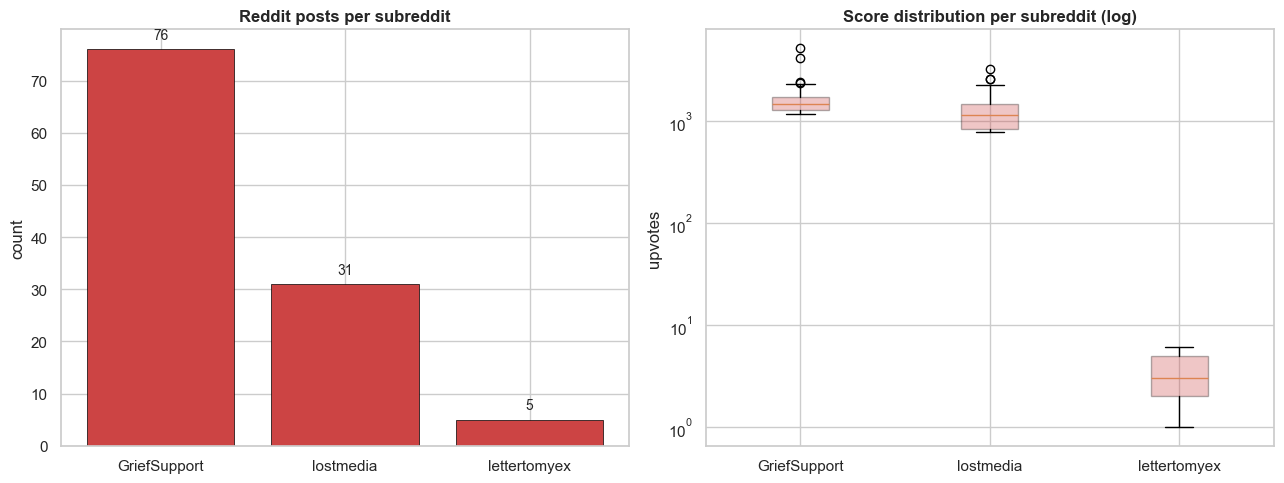

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = reddit_df["subreddit"].value_counts()
axes[0].bar(counts.index, counts.values, color="#cc4444", edgecolor="black", linewidth=0.5)
axes[0].set_title("Reddit posts per subreddit", weight="bold")
axes[0].set_ylabel("count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(int(v)), ha="center", fontsize=10)

axes[1].boxplot([reddit_df[reddit_df["subreddit"] == s]["score"].values for s in counts.index],
                tick_labels=list(counts.index), patch_artist=True,
                boxprops=dict(facecolor="#cc4444", alpha=0.3))
axes[1].set_yscale("log")
axes[1].set_title("Score distribution per subreddit (log)", weight="bold")
axes[1].set_ylabel("upvotes")

plt.tight_layout()
plt.savefig(OUT_DIR / "01_reddit_overview.png", dpi=160, bbox_inches="tight")
plt.show()

## Figure 2 — Wayback snapshots by domain × decade

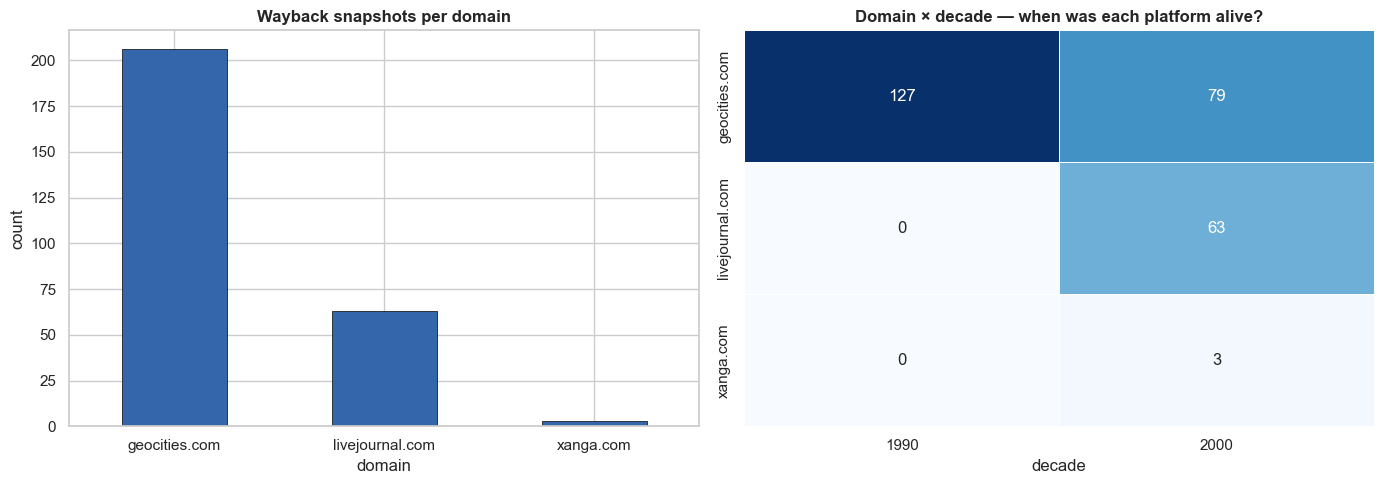

In [6]:
ts = pd.to_datetime(wayback_df["timestamp"], format="%Y%m%d%H%M%S", errors="coerce", utc=True)
wayback_df["year"]   = ts.dt.year
wayback_df["decade"] = (wayback_df["year"] // 10 * 10).astype("Int64")

heat = (wayback_df.groupby(["domain", "decade"]).size().unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
wayback_df["domain"].value_counts().plot.bar(ax=axes[0], color="#3366aa", edgecolor="black", linewidth=0.5)
axes[0].set_title("Wayback snapshots per domain", weight="bold")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

sns.heatmap(heat, ax=axes[1], annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5, linecolor="white")
axes[1].set_title("Domain × decade — when was each platform alive?", weight="bold")
axes[1].set_xlabel("decade"); axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUT_DIR / "02_wayback_overview.png", dpi=160, bbox_inches="tight")
plt.show()

## Figure 3 — LoC photographs by coarse subject + by date range

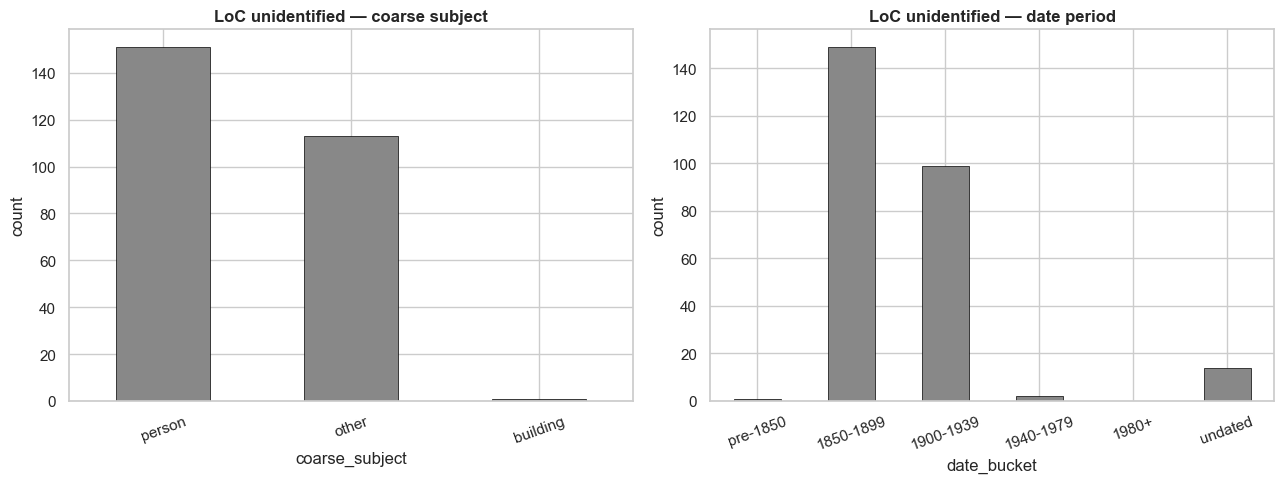

In [7]:
def coarse_subject(s):
    s = (str(s) or "").lower()
    if any(k in s for k in ["portrait", "person", "soldier", "family", "woman", "man", "child"]): return "person"
    if any(k in s for k in ["build", "architect", "house", "factory", "hotel"]): return "building"
    if any(k in s for k in ["landscape", "view", "countryside", "mountain"]): return "landscape"
    if any(k in s for k in ["object", "still life", "interior", "furniture"]): return "object"
    return "other"
loc_df["coarse_subject"] = loc_df["subject"].apply(coarse_subject)

def year_bucket(s):
    s = str(s)
    m = re.search(r"(1[6-9]\d{2}|20\d{2})", s)
    if not m: return "undated"
    y = int(m.group(1))
    if y < 1850: return "pre-1850"
    if y < 1900: return "1850-1899"
    if y < 1940: return "1900-1939"
    if y < 1980: return "1940-1979"
    return "1980+"
loc_df["date_bucket"] = loc_df["date"].apply(year_bucket)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
loc_df["coarse_subject"].value_counts().plot.bar(
    ax=axes[0], color="#888888", edgecolor="black", linewidth=0.5)
axes[0].set_title("LoC unidentified — coarse subject", weight="bold")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)

order = ["pre-1850", "1850-1899", "1900-1939", "1940-1979", "1980+", "undated"]
loc_df["date_bucket"].value_counts().reindex(order).plot.bar(
    ax=axes[1], color="#888888", edgecolor="black", linewidth=0.5)
axes[1].set_title("LoC unidentified — date period", weight="bold")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(OUT_DIR / "03_loc_overview.png", dpi=160, bbox_inches="tight")
plt.show()

## Figure 4 — Cross-dataset theme heatmap

Hand-curated list of *thematic anchors* relevant to the project's thesis. For each, count what fraction of documents in each source contain that anchor word.

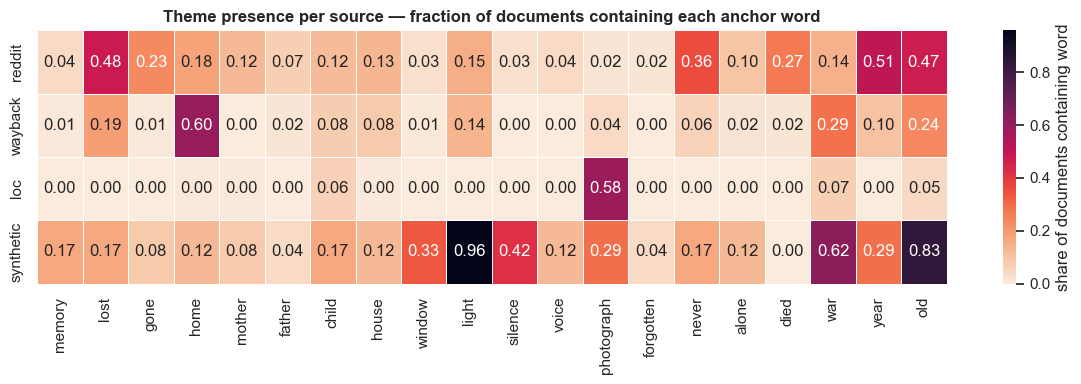

In [8]:
THEMES = ["memory", "lost", "gone", "home", "mother", "father", "child",
          "house", "window", "light", "silence", "voice", "photograph",
          "forgotten", "never", "alone", "died", "war", "year", "old"]

def fraction_with_word(texts, word):
    word = word.lower()
    return float(np.mean([word in str(t).lower() for t in texts]))

sources = {
    "reddit":    reddit_df["combined_text"],
    "wayback":   wayback_df["combined_text"],
    "loc":       loc_df["combined_text"],
}
if not syn_df.empty:
    syn_text = (syn_df.get("room","").fillna("") + " " + syn_df.get("monologue","").fillna("")).tolist()
    sources["synthetic"] = pd.Series(syn_text)

M = np.array([[fraction_with_word(sources[s], w) for w in THEMES] for s in sources.keys()])
heat_df = pd.DataFrame(M, index=list(sources.keys()), columns=THEMES)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="rocket_r", linewidths=0.5,
            cbar_kws={"label":"share of documents containing word"}, ax=ax)
ax.set_title("Theme presence per source — fraction of documents containing each anchor word", weight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_theme_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

## Figure 5 — Inhabitant monologue language vs source corpora

Compare the 20 most frequent content words in the synthetic monologues to their frequency in the three source corpora. Where the synthetic vocabulary tracks the source distribution = GPT is faithfully channeling the corpus. Where it diverges = GPT is inserting its own register.

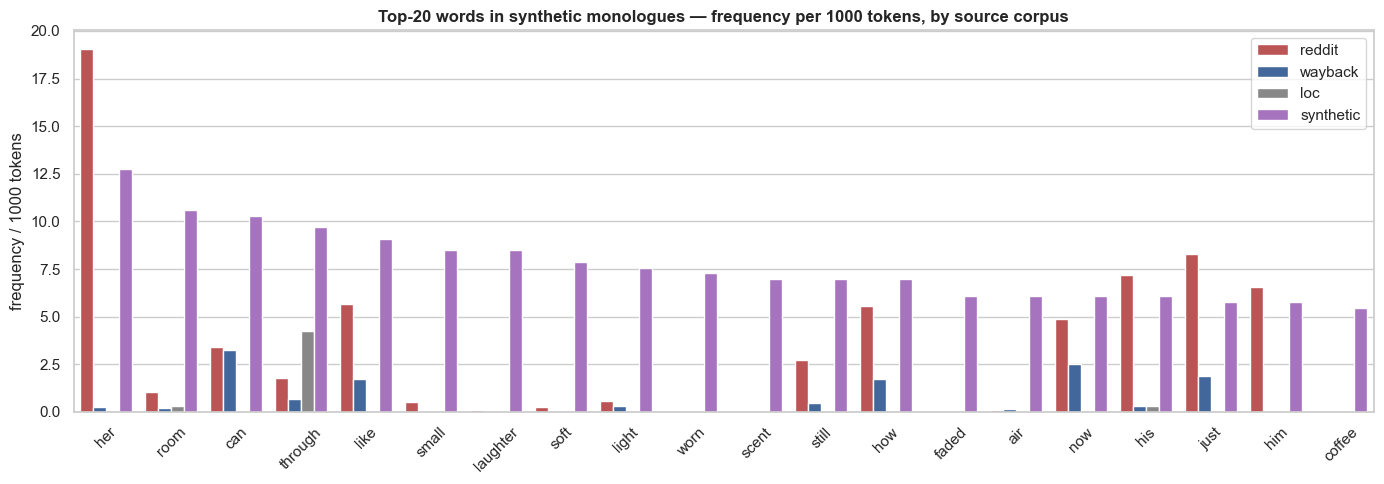

In [9]:
if syn_df.empty:
    print("No synthetic data yet -- skip this cell")
else:
    import string
    STOP = set(("the a an and or but if then of to in on at by for with as from is are was were be been being it its he she they them their this that those these i you my your we us our not no s t m re ve d ll").split())
    def tokens(t):
        t = re.sub(r"[^a-zA-Z\s']", " ", str(t).lower())
        return [w for w in t.split() if w and w not in STOP and len(w) > 2]

    syn_text = " ".join((syn_df.get("room","").fillna("") + " " + syn_df.get("monologue","").fillna("")).tolist())
    syn_counts = Counter(tokens(syn_text))
    top20 = [w for w, _ in syn_counts.most_common(20)]

    source_text = {
        "reddit":  " ".join(reddit_df["combined_text"].astype(str).tolist()),
        "wayback": " ".join(wayback_df["combined_text"].astype(str).tolist()),
        "loc":     " ".join(loc_df["combined_text"].astype(str).tolist()),
    }
    rows = []
    for w in top20:
        for s, txt in source_text.items():
            rows.append({"word":w, "source":s, "freq_per_1000": tokens(txt).count(w) * 1000.0 / max(1, len(tokens(txt)))})
        rows.append({"word":w, "source":"synthetic", "freq_per_1000": tokens(syn_text).count(w) * 1000.0 / max(1, len(tokens(syn_text)))})
    freq_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=freq_df, x="word", y="freq_per_1000", hue="source",
                palette=SRC_COLORS, ax=ax)
    ax.set_title("Top-20 words in synthetic monologues — frequency per 1000 tokens, by source corpus", weight="bold")
    ax.set_ylabel("frequency / 1000 tokens"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="", loc="upper right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "05_synthetic_vs_sources.png", dpi=160, bbox_inches="tight")
    plt.show()

## Figure 6 — Source × cluster heatmap (THE signature figure)

For each of the 20 clusters, show how its members are distributed across the four sources. Bright squares away from the diagonal of any one source = the cluster is *mixed*, i.e. an AI mis-classification. This is the figure the report should anchor around.

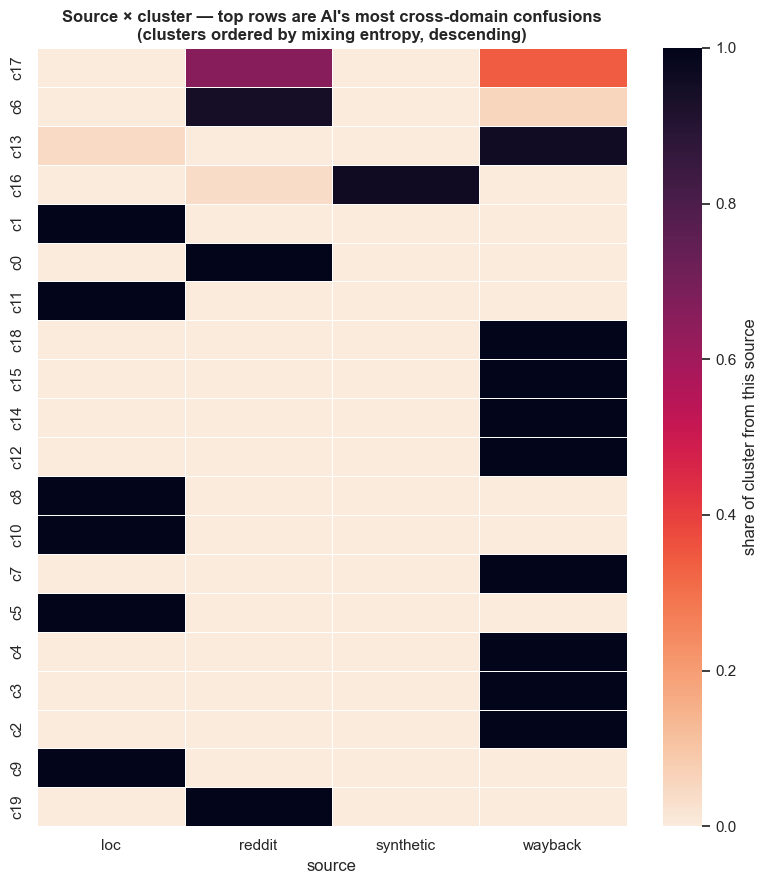

In [10]:
mat = (cluster_df.groupby(["cluster", "source"]).size().unstack(fill_value=0))
# row-normalize so each row sums to 1 -> share of that cluster from each source
mat_norm = mat.div(mat.sum(axis=1), axis=0)
# reorder rows by mixing entropy (top of report figure = most mixed)
order = frag_df.sort_values("mixing_entropy", ascending=False)["cluster"].tolist()
mat_norm = mat_norm.loc[order]

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(mat_norm, annot=False, cmap="rocket_r",
            yticklabels=[f"c{c}" for c in mat_norm.index],
            linewidths=0.4, linecolor="white",
            cbar_kws={"label":"share of cluster from this source"}, ax=ax)
ax.set_title("Source × cluster — top rows are AI's most cross-domain confusions\n(clusters ordered by mixing entropy, descending)", weight="bold")
ax.set_xlabel("source"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_source_x_cluster_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

## Figure 7 — Mixing entropy × cluster size phase diagram

Each dot is one cluster = one architectural fragment. The horizontal axis is how confused the AI is about that cluster (high = bad reading = good for project). The vertical axis is cluster size (popularity). The size of the marker is the number of sources represented. Annotated with the cluster ID, so the report can talk about *fragment 1, the top-right cluster*, etc.

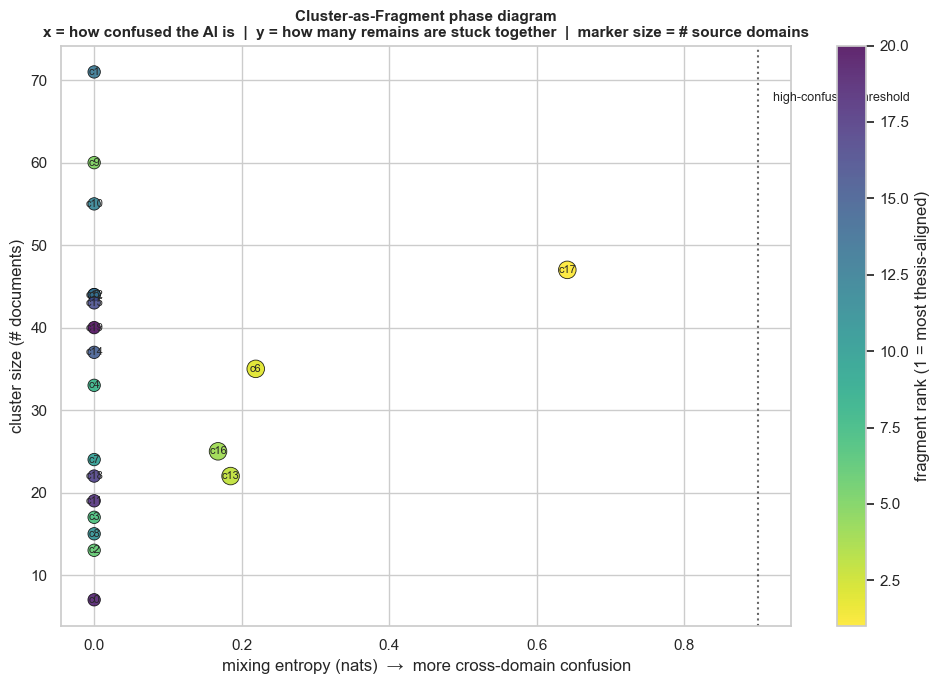

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    frag_df["mixing_entropy"], frag_df["size"],
    s=frag_df["n_sources"]*80, c=frag_df["rank"], cmap="viridis_r",
    edgecolor="black", linewidth=0.6, alpha=0.85,
)
for _, r in frag_df.iterrows():
    ax.annotate(f"c{int(r['cluster'])}", (r["mixing_entropy"], r["size"]),
                fontsize=8, ha="center", va="center")
ax.set_xlabel("mixing entropy (nats)  →  more cross-domain confusion")
ax.set_ylabel("cluster size (# documents)")
ax.set_title("Cluster-as-Fragment phase diagram\nx = how confused the AI is  |  y = how many remains are stuck together  |  marker size = # source domains",
             weight="bold", fontsize=11)
ax.axvline(0.9, color="black", linestyle=":", alpha=0.6)
ax.text(0.92, frag_df["size"].max()*0.95, "high-confusion threshold", fontsize=9)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("fragment rank (1 = most thesis-aligned)")
plt.tight_layout()
plt.savefig(OUT_DIR / "07_phase_diagram.png", dpi=160, bbox_inches="tight")
plt.show()

## Figure 8 — Stratified archive cross-section

A schematic, architectural-style 'soil section' through the three strata of digital remains. Each stratum is drawn proportional to its document count, and is overlaid with the cluster bubbles that cross it. This is the project's metaphor made literal — the *archive as geology*. Less a chart, more a diagram for inclusion alongside the report's introduction.

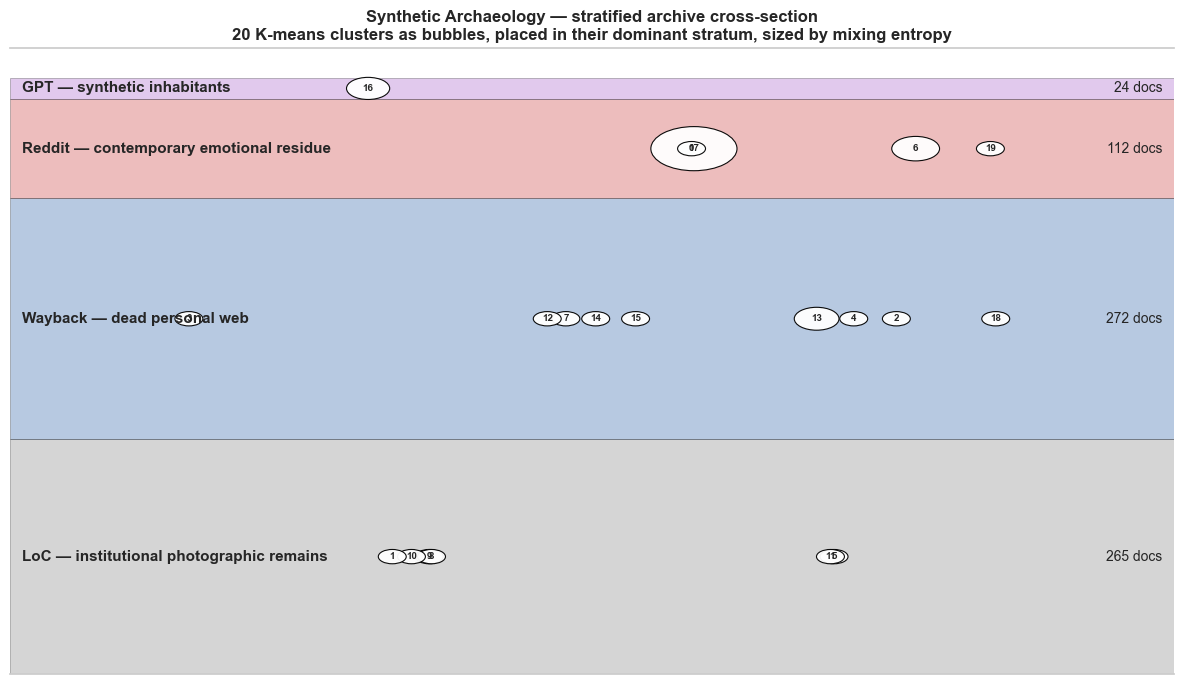

In [12]:
from matplotlib.patches import Rectangle, Circle

src_counts = cluster_df["source"].value_counts()
STRATA_ORDER = ["loc", "wayback", "reddit", "synthetic"]   # top (deepest in time) -> bottom (most recent)
STRATA_LABELS = {
    "loc":       "LoC — institutional photographic remains",
    "wayback":   "Wayback — dead personal web",
    "reddit":    "Reddit — contemporary emotional residue",
    "synthetic": "GPT — synthetic inhabitants",
}

fig, ax = plt.subplots(figsize=(12, 7))
y = 0.0
stratum_y = {}
for s in STRATA_ORDER:
    h = src_counts.get(s, 0) / max(1, src_counts.sum()) * 1.0
    if h <= 0: continue
    ax.add_patch(Rectangle((0, y), 1.0, h, facecolor=SRC_COLORS[s], alpha=0.35, edgecolor="black", linewidth=0.5))
    ax.text(0.01, y + h/2, STRATA_LABELS[s], va="center", fontsize=11, weight="bold")
    ax.text(0.99, y + h/2, f"{int(src_counts.get(s, 0))} docs", va="center", ha="right", fontsize=10)
    stratum_y[s] = y + h/2
    y += h

# overlay cluster bubbles, positioned by dominant source
rng = np.random.default_rng(7)
for _, r in frag_df.iterrows():
    shares = {s: r.get(f"share_{s}", 0) for s in STRATA_ORDER}
    dom = max(shares, key=shares.get)
    yc  = stratum_y.get(dom, 0.5)
    xc  = rng.uniform(0.15, 0.85)
    rad = 0.012 + 0.025 * (r["mixing_entropy"] / max(0.0001, frag_df["mixing_entropy"].max()))
    ax.add_patch(Circle((xc, yc), rad,
                        facecolor="#aa66cc" if r["mixing_entropy"] > 0.9 else "white",
                        edgecolor="black", linewidth=0.8, alpha=0.95))
    ax.text(xc, yc, f"{int(r['cluster'])}", fontsize=7, ha="center", va="center", weight="bold")

ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_xticks([]); ax.set_yticks([])
ax.spines["left"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_title("Synthetic Archaeology — stratified archive cross-section\n20 K-means clusters as bubbles, placed in their dominant stratum, sized by mixing entropy",
             weight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "08_stratified_archive.png", dpi=160, bbox_inches="tight")
plt.show()

## Summary of figures saved

In [13]:
for f in sorted(OUT_DIR.glob("*.png")):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")

  01_reddit_overview.png  (50 KB)
  02_wayback_overview.png  (64 KB)
  03_loc_overview.png  (62 KB)
  04_theme_heatmap.png  (132 KB)
  05_synthetic_vs_sources.png  (82 KB)
  06_source_x_cluster_heatmap.png  (73 KB)
  07_phase_diagram.png  (108 KB)
  08_stratified_archive.png  (98 KB)
